# **Natural Language Processing Lab**

## Text Representation

### Objectives


- Convert text into numerical vectors.
- Compare different vectorization methods.
- Visualize how machines interpret text.
- Build a simple interactive NLP application using Gradio.

**Libraries**

In [5]:
!pip install nltk spacy wordcloud gradio contractions

!python -m spacy download en_core_web_sm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 12.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 58.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


# **TEXT REPRESENTATION**

**Text to Value**

Machine Learning models cannot understand text directly.

Before using text in a model, we first convert words into numbers.

One of the simplest methods is **Label Encoding**, where each unique word is assigned a unique integer.

In [6]:
import pandas as pd

# -----------------------------
# Step 1: Create Sample Dataset
# -----------------------------
df = pd.DataFrame({
    'text': [
        'he cooks food',
        'food cooks good',
        'food smells good',
        'food is food'
    ],
    'output': [0, 1, 1, 0]
})

print("Original Dataset\n")
print(df)

# -----------------------------
# Step 2: Build Vocabulary
# -----------------------------
vocabulary = []

for sentence in df['text']:
    for word in sentence.split():
        if word not in vocabulary:
            vocabulary.append(word)

print("\nVocabulary:")
print(vocabulary)

# -----------------------------
# Step 3: Assign Numeric Values
# -----------------------------
word_to_value = {}

for i, word in enumerate(vocabulary):
    word_to_value[word] = i

print("\nText to Numeric Value Mapping:")
print(word_to_value)

# -----------------------------
# Step 4: Convert Each Sentence
# -----------------------------
print("\nSentences Converted to Numbers:\n")

for sentence in df['text']:
    numbers = []

    for word in sentence.split():
        numbers.append(word_to_value[word])

    print(f"{sentence}")
    print(f"-> {numbers}\n")

Original Dataset

               text  output
0     he cooks food       0
1   food cooks good       1
2  food smells good       1
3      food is food       0

Vocabulary:
['he', 'cooks', 'food', 'good', 'smells', 'is']

Text to Numeric Value Mapping:
{'he': 0, 'cooks': 1, 'food': 2, 'good': 3, 'smells': 4, 'is': 5}

Sentences Converted to Numbers:

he cooks food
-> [0, 1, 2]

food cooks good
-> [2, 1, 3]

food smells good
-> [2, 4, 3]

food is food
-> [2, 5, 2]



## One-Hot Encoding (OHE)

Machine Learning algorithms cannot directly understand words. They require numerical input.

One-Hot Encoding is one of the simplest methods to convert words into vectors.

### How does it work?

Step 1: Build a vocabulary (all unique words).

Example:

Sentence:
"I love NLP"

Vocabulary:

["I", "love", "NLP"]


### Example

| Word | One-Hot Vector |
|------|----------------|
| I | [1,0,0] |
| love | [0,1,0] |
| NLP | [0,0,1] |

### Advantages

- Very easy to understand.
- Easy to implement.
- Useful for small vocabularies.

### Limitations

- High dimensional vectors.
- Sparse representation (mostly zeros).
- Does not capture semantic meaning.
- "AI" and "Artificial Intelligence" appear completely unrelated.


In [7]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# Sample Words
words = ["I", "love", "NLP", "love", "AI", "Machine", "Learning"]

print("Original Words:")
print(words)

Original Words:
['I', 'love', 'NLP', 'love', 'AI', 'Machine', 'Learning']


In [8]:
# Convert to DataFrame
df = pd.DataFrame(words, columns=["Word"])

df

,Word
0,I
1,love
2,NLP
3,love
4,AI
5,Machine
6,Learning


In [9]:
# Initialize Encoder
encoder = OneHotEncoder(sparse_output=False)

# Fit and Transform
encoded = encoder.fit_transform(df)

print(encoded)

[[0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0. 0.]]


**Another Example**

In [10]:
# ==========================================================
# One-Hot Encoding (OHE) - Visual Demonstration
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# -----------------------------
# Sample Dataset
# -----------------------------
df = pd.DataFrame({
    "Student": ["Ali", "Sara", "Ahmed", "Ayesha", "Hamza", "Fatima",
                "Usman", "Zain", "Hina", "Noor"],
    "Favorite_Subject": [
        "AI", "Web", "AI", "Cyber", "Data Science",
        "Web", "AI", "Cyber", "Data Science", "Web"
    ]
})

print("\nOriginal Dataset\n")
display(df)







Original Dataset



,Student,Favorite_Subject
0,Ali,AI
1,Sara,Web
2,Ahmed,AI
3,Ayesha,Cyber
4,Hamza,Data Science
5,Fatima,Web
6,Usman,AI
7,Zain,Cyber
8,Hina,Data Science
9,Noor,Web


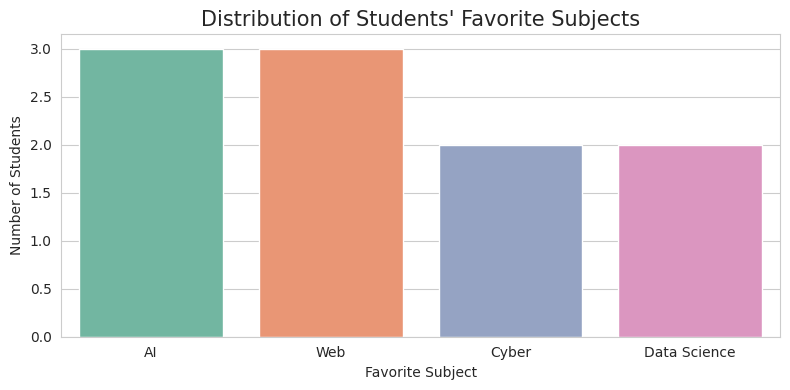

In [11]:
# -----------------------------
# Original Category Distribution
# -----------------------------
plt.figure(figsize=(8,4))
sns.countplot(
    data=df,
    x="Favorite_Subject",
    hue="Favorite_Subject",
    palette="Set2",
    legend=False
)

plt.title("Distribution of Students' Favorite Subjects", fontsize=15)
plt.xlabel("Favorite Subject")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.show()



In [12]:
# -----------------------------
# One-Hot Encoding
# -----------------------------
encoded_df = pd.get_dummies(
    df,
    columns=["Favorite_Subject"],
    dtype=int
)

print("\nOne-Hot Encoded Dataset\n")
display(encoded_df)




One-Hot Encoded Dataset



,Student,Favorite_Subject_AI,Favorite_Subject_Cyber,Favorite_Subject_Data Science,Favorite_Subject_Web
0,Ali,1,0,0,0
1,Sara,0,0,0,1
2,Ahmed,1,0,0,0
3,Ayesha,0,1,0,0
4,Hamza,0,0,1,0
5,Fatima,0,0,0,1
6,Usman,1,0,0,0
7,Zain,0,1,0,0
8,Hina,0,0,1,0
9,Noor,0,0,0,1


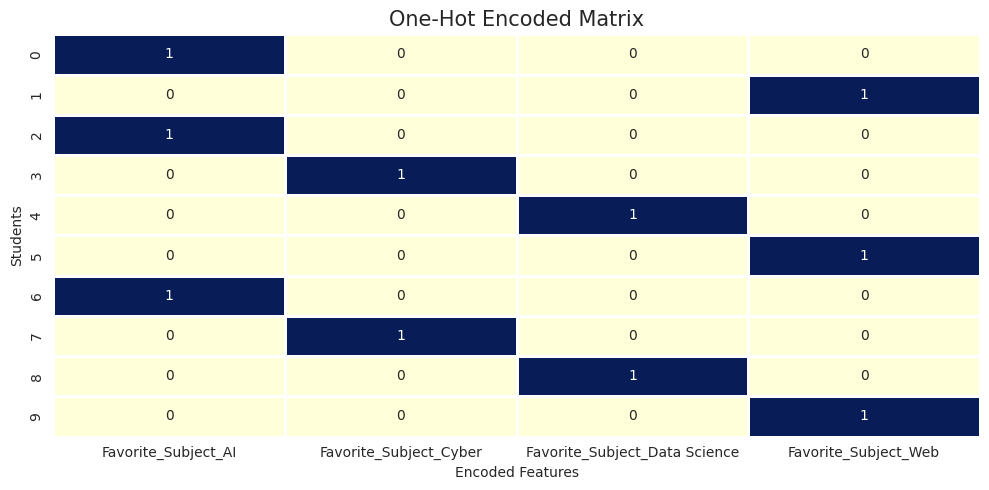

In [13]:
# -----------------------------
# Heatmap of Encoded Data
# -----------------------------
ohe_cols = [col for col in encoded_df.columns if "Favorite_Subject_" in col]

plt.figure(figsize=(10,5))
sns.heatmap(
    encoded_df[ohe_cols],
    annot=True,
    cmap="YlGnBu",
    linewidths=1,
    cbar=False,
    fmt="d"
)

plt.title("One-Hot Encoded Matrix", fontsize=15)
plt.xlabel("Encoded Features")
plt.ylabel("Students")
plt.tight_layout()
plt.show()

In [11]:
# ==========================================================
# One-Hot Encoding Visualizer
# ==========================================================

!pip -q install gradio

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import gradio as gr

sns.set_style("whitegrid")

def one_hot_visualizer(text):

    # Input
    categories = [x.strip() for x in text.split(",") if x.strip()]

    if len(categories) == 0:
        return None, None

    # Original DataFrame
    df = pd.DataFrame({"Category": categories})

    # One Hot Encoding
    encoded = pd.get_dummies(df, columns=["Category"], dtype=int)

    # Heatmap
    cols = [c for c in encoded.columns if c.startswith("Category_")]

    plt.figure(figsize=(max(6,len(cols)), max(3,len(df)/2)))

    sns.heatmap(
        encoded[cols],
        annot=True,
        cmap="YlGnBu",
        linewidths=1,
        cbar=False,
        fmt="d"
    )

    plt.title("One-Hot Encoding Matrix")
    plt.xlabel("Encoded Features")
    plt.ylabel("Samples")
    plt.tight_layout()

    return encoded, plt.gcf()


demo = gr.Interface(
    fn=one_hot_visualizer,
    inputs=gr.Textbox(
        lines=2,
        label="Enter Categories (comma separated)",
        placeholder="Apple, Banana, Apple, Mango, Banana, Orange"
    ),
    outputs=[
        gr.Dataframe(label="One-Hot Encoded Data"),
        gr.Plot(label="Visualization")
    ],
    title="🎓 One-Hot Encoding (OHE) Visualizer",
    description="""
Type any categorical values separated by commas.

Examples:

Apple, Banana, Apple, Mango

Cat, Dog, Bird, Dog, Cat

Red, Blue, Green, Blue

AI, Web, AI, Cyber, Data Science
"""
)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b20856232e4162a53c.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# Text Representation using Bag of Words (BoW)

## What is Bag of Words (BoW)?

Bag of Words (BoW) is one of the simplest and most widely used techniques for converting text into numerical vectors.

Unlike One-Hot Encoding, which represents each word individually, BoW represents an entire document by counting how many times each word appears.

The order of words is ignored; only the frequency (count) of each word is considered.

---

## How Does Bag of Words Work?

### Step 1: Collect Documents

Document 1:
"I love NLP"

Document 2:
"I love Machine Learning"

---

### Step 2: Create Vocabulary

Vocabulary =

[I, love, NLP, Machine, Learning]

---

### Step 3: Count Word Frequency

| Document | I | love | NLP | Machine | Learning |
|-----------|---|------|-----|----------|----------|
| Doc 1 | 1 | 1 | 1 | 0 | 0 |
| Doc 2 | 1 | 1 | 0 | 1 | 1 |

Each row represents a document.

Each column represents a unique word.

Each value represents the frequency of that word in the document.

---

## Advantages

- Simple and easy to understand.
- Fast to implement.
- Works well for many classical Machine Learning algorithms.
- Represents complete documents.

---

## Limitations

- Ignores word order.
- Ignores semantic meaning.
- Produces sparse vectors for large vocabularies.

In [15]:
documents = [
    "I love NLP",
    "I love Machine Learning",
    "Machine Learning is amazing",
    "NLP makes computers understand language"
]

print("Documents:\n")

for i, doc in enumerate(documents, start=1):
    print(f"Document {i}: {doc}")

Documents:

Document 1: I love NLP
Document 2: I love Machine Learning
Document 3: Machine Learning is amazing
Document 4: NLP makes computers understand language


Create Bag of Words

In [16]:
from sklearn.feature_extraction.text import CountVectorizer

# Initialize CountVectorizer
vectorizer = CountVectorizer()

# Fit and Transform
bow_matrix = vectorizer.fit_transform(documents)

In [17]:
print("Vocabulary:\n")

print(vectorizer.get_feature_names_out())

Vocabulary:

['amazing' 'computers' 'is' 'language' 'learning' 'love' 'machine' 'makes'
 'nlp' 'understand']


In [18]:
import pandas as pd

bow_df = pd.DataFrame(
    bow_matrix.toarray(),
    columns=vectorizer.get_feature_names_out(),
    index=[f"Document {i+1}" for i in range(len(documents))]
)

display(bow_df)

,amazing,computers,is,language,learning,love,machine,makes,nlp,understand
Document 1,0,0,0,0,0,1,0,0,1,0
Document 2,0,0,0,0,1,1,1,0,0,0
Document 3,1,0,1,0,1,0,1,0,0,0
Document 4,0,1,0,1,0,0,0,1,1,1


Original Movie Reviews
Review 1: The movie was amazing amazing amazing
Review 2: The movie was boring
Review 3: Amazing acting and amazing story
Review 4: The story was boring but acting was amazing


Bag of Words Matrix


,acting,amazing,and,boring,but,movie,story,the,was
Review 1,0,3,0,0,0,1,0,1,1
Review 2,0,0,0,1,0,1,0,1,1
Review 3,1,2,1,0,0,0,1,0,0
Review 4,1,1,0,1,1,0,1,1,2


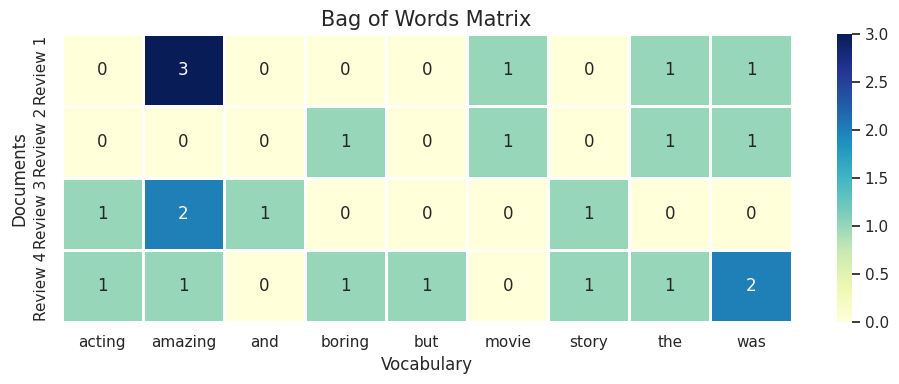

In [19]:
# ============================================================
# BAG OF WORDS (BoW) - Complete Demonstration
# Example: Movie Reviews
# ============================================================

from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

# ------------------------------------------------------------
# Step 1: Sample Documents
# ------------------------------------------------------------

documents = [
    "The movie was amazing amazing amazing",
    "The movie was boring",
    "Amazing acting and amazing story",
    "The story was boring but acting was amazing"
]

doc_names = [
    "Review 1",
    "Review 2",
    "Review 3",
    "Review 4"
]

print("="*80)
print("Original Movie Reviews")
print("="*80)

for name, doc in zip(doc_names, documents):
    print(f"{name}: {doc}")

# ------------------------------------------------------------
# Step 2: Create Bag of Words
# ------------------------------------------------------------

vectorizer = CountVectorizer()

bow = vectorizer.fit_transform(documents)

bow_df = pd.DataFrame(
    bow.toarray(),
    columns=vectorizer.get_feature_names_out(),
    index=doc_names
)

print("\n")
print("="*80)
print("Bag of Words Matrix")
print("="*80)

display(bow_df)

# ------------------------------------------------------------
# Step 3: Heatmap
# ------------------------------------------------------------

plt.figure(figsize=(10,4))

sns.heatmap(
    bow_df,
    annot=True,
    cmap="YlGnBu",
    linewidths=1,
    fmt="d"
)

plt.title("Bag of Words Matrix", fontsize=15)
plt.xlabel("Vocabulary")
plt.ylabel("Documents")
plt.tight_layout()
plt.show()



In [10]:
# ==========================================================
# Live Bag of Words (BoW) Visualizer
# ==========================================================

!pip -q install gradio

import gradio as gr
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer

sns.set_theme(style="whitegrid")

# ----------------------------------------------------------
# Function
# ----------------------------------------------------------

def bow_demo(text):

    if text.strip() == "":
        return None, None, None

    # Split sentences using new lines
    documents = [doc.strip() for doc in text.split("\n") if doc.strip()]

    vectorizer = CountVectorizer()

    bow = vectorizer.fit_transform(documents)

    bow_df = pd.DataFrame(
        bow.toarray(),
        columns=vectorizer.get_feature_names_out(),
        index=[f"Document {i+1}" for i in range(len(documents))]
    )

    # ---------------- Heatmap ----------------

    plt.figure(figsize=(max(8,len(bow_df.columns)), max(3,len(documents))))

    sns.heatmap(
        bow_df,
        annot=True,
        cmap="YlGnBu",
        linewidths=1,
        fmt="d"
    )

    plt.title("Bag of Words Matrix")
    plt.tight_layout()

    heatmap = plt.gcf()
    plt.close()

    # ---------------- Bar Chart ----------------

    word_counts = bow_df.sum().sort_values(ascending=False)

    plt.figure(figsize=(8,4))

    sns.barplot(
        x=word_counts.values,
        y=word_counts.index,
        palette="viridis"
    )

    plt.title("Total Word Frequency")
    plt.xlabel("Count")
    plt.ylabel("Word")
    plt.tight_layout()

    bar = plt.gcf()
    plt.close()

    return bow_df, heatmap, bar


# ----------------------------------------------------------
# Interface
# ----------------------------------------------------------

examples = [[
"""I love AI
I love Machine Learning
AI is amazing
Machine Learning loves data"""
],
[
"""Pizza Pizza Burger
Burger Fries Pizza
Fries Fries Burger"""
],
[
"""Cat Dog Cat
Dog Bird
Cat Bird Bird"""
]
]

demo = gr.Interface(
    fn=bow_demo,

    inputs=gr.Textbox(
        lines=8,
        label="Enter Documents (One Document Per Line)",
        placeholder="""Example:

I love AI
I love Machine Learning
AI is amazing
Machine Learning loves data"""
    ),

    outputs=[
        gr.Dataframe(label="Bag of Words Matrix"),
        gr.Plot(label="Heatmap"),
        gr.Plot(label="Word Frequency")
    ],

    examples=examples,

    title="📚 Live Bag of Words (BoW) Visualizer",

    description="""
Type multiple documents (one per line).

The application will automatically:

✅ Build the vocabulary

✅ Count the frequency of every word

✅ Create the Bag of Words Matrix

✅ Display a colorful Heatmap

✅ Display Word Frequency
"""
)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b1e0f506ddb41c8e56.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [21]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

# Sample Documents
documents = [
    "I love AI",
    "I love AI AI"
]

print("=" * 70)
print("Documents")
print("=" * 70)

for i, doc in enumerate(documents, start=1):
    print(f"Document {i}: {doc}")

# -----------------------------------------------------
# One-Hot Encoding
# -----------------------------------------------------

print("\n" + "=" * 70)
print("One-Hot Encoding")
print("=" * 70)

words = ["I", "love", "AI", "AI"]

encoder = OneHotEncoder(sparse_output=False)

ohe = encoder.fit_transform(pd.DataFrame(words, columns=["Word"]))

ohe_df = pd.DataFrame(
    ohe,
    columns=encoder.categories_[0]
)

print(ohe_df)

# -----------------------------------------------------
# Bag of Words
# -----------------------------------------------------

print("\n" + "=" * 70)
print("Bag of Words")
print("=" * 70)

vectorizer = CountVectorizer()

bow = vectorizer.fit_transform(documents)

bow_df = pd.DataFrame(
    bow.toarray(),
    columns=vectorizer.get_feature_names_out(),
    index=["Document 1", "Document 2"]
)

print(bow_df)

# -----------------------------------------------------
# Comparison
# -----------------------------------------------------

print("\n" + "=" * 70)
print("Comparison")
print("=" * 70)

print("""
One-Hot Encoding
----------------
✓ Represents ONE WORD at a time
✓ Shows only the presence of a word
✗ Cannot represent an entire document
✗ Does not count word frequency

Bag of Words
------------
✓ Represents the COMPLETE DOCUMENT
✓ Counts how many times each word appears
✓ More informative for Machine Learning
✓ Better document representation
""")

Documents
Document 1: I love AI
Document 2: I love AI AI

One-Hot Encoding
    AI    I  love
0  0.0  1.0   0.0
1  0.0  0.0   1.0
2  1.0  0.0   0.0
3  1.0  0.0   0.0

Bag of Words
            ai  love
Document 1   1     1
Document 2   2     1

Comparison

One-Hot Encoding
----------------
✓ Represents ONE WORD at a time
✓ Shows only the presence of a word
✗ Cannot represent an entire document
✗ Does not count word frequency

Bag of Words
------------
✓ Represents the COMPLETE DOCUMENT
✓ Counts how many times each word appears
✓ More informative for Machine Learning
✓ Better document representation



# Text Representation using N-Grams

## What are N-Grams?

An **N-Gram** is a sequence of **N consecutive words** from a sentence.

Unlike Bag of Words, which treats each word independently, N-Grams preserve some of the word order and context.

---

## Types of N-Grams

### 1. Unigram (N = 1)

Sentence:

"I love Natural Language Processing"

Output:

[I] [love] [Natural] [Language] [Processing]

---

### 2. Bigram (N = 2)

Sentence:

"I love Natural Language Processing"

Output:

[I love]

[love Natural]

[Natural Language]

[Language Processing]

---

### 3. Trigram (N = 3)

Sentence:

"I love Natural Language Processing"

Output:

[I love Natural]

[love Natural Language]

[Natural Language Processing]

---

## Advantages

- Preserves local word order.
- Captures phrases such as "Machine Learning".
- Performs better than Bag of Words for many NLP tasks.

---

## Limitations

- Vocabulary size grows rapidly.
- Produces larger feature vectors.
- Still does not fully capture long-range context.

In [22]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

documents = [
    "I love Natural Language Processing",
    "Natural Language Processing is amazing"
]

# Unigram
vectorizer = CountVectorizer(ngram_range=(1,1))

X = vectorizer.fit_transform(documents)

unigram_df = pd.DataFrame(
    X.toarray(),
    columns=vectorizer.get_feature_names_out(),
    index=["Document 1","Document 2"]
)

print("Unigram Representation\n")
display(unigram_df)

Unigram Representation



,amazing,is,language,love,natural,processing
Document 1,0,0,1,1,1,1
Document 2,1,1,1,0,1,1


In [23]:
# Bigram
vectorizer = CountVectorizer(ngram_range=(2,2))

X = vectorizer.fit_transform(documents)

bigram_df = pd.DataFrame(
    X.toarray(),
    columns=vectorizer.get_feature_names_out(),
    index=["Document 1","Document 2"]
)

print("Bigram Representation\n")
display(bigram_df)

Bigram Representation



,is amazing,language processing,love natural,natural language,processing is
Document 1,0,1,1,1,0
Document 2,1,1,0,1,1


In [24]:
# Trigram
vectorizer = CountVectorizer(ngram_range=(3,3))

X = vectorizer.fit_transform(documents)

trigram_df = pd.DataFrame(
    X.toarray(),
    columns=vectorizer.get_feature_names_out(),
    index=["Document 1","Document 2"]
)

print("Trigram Representation\n")
display(trigram_df)

Trigram Representation



,language processing is,love natural language,natural language processing,processing is amazing
Document 1,0,1,1,0
Document 2,1,0,1,1


In [25]:
from sklearn.feature_extraction.text import CountVectorizer

sentence = ["I love Natural Language Processing"]

print("="*60)
print("UNIGRAMS")
print("="*60)

uni = CountVectorizer(ngram_range=(1,1))
uni.fit(sentence)
print(list(uni.get_feature_names_out()))

print("\n"+"="*60)
print("BIGRAMS")
print("="*60)

bi = CountVectorizer(ngram_range=(2,2))
bi.fit(sentence)
print(list(bi.get_feature_names_out()))

print("\n"+"="*60)
print("TRIGRAMS")
print("="*60)

tri = CountVectorizer(ngram_range=(3,3))
tri.fit(sentence)
print(list(tri.get_feature_names_out()))

UNIGRAMS
['language', 'love', 'natural', 'processing']

BIGRAMS
['language processing', 'love natural', 'natural language']

TRIGRAMS
['love natural language', 'natural language processing']


In [26]:
# ==========================================================
# Live N-Gram Visualizer
# ==========================================================

!pip -q install gradio

import gradio as gr
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer

sns.set_theme(style="whitegrid")


# ----------------------------------------------------------
# Function
# ----------------------------------------------------------

def ngram_demo(text, n):

    text = text.strip()

    if text == "":
        return None, None, None, None

    # Generate n-grams
    vectorizer = CountVectorizer(ngram_range=(n, n))

    X = vectorizer.fit_transform([text])

    vocabulary = vectorizer.get_feature_names_out()

    # DataFrame
    bow_df = pd.DataFrame(
        X.toarray(),
        columns=vocabulary,
        index=["Sentence"]
    )

    # List of n-grams
    ngram_df = pd.DataFrame({
        f"{n}-Gram": vocabulary
    })

    # ---------------------------
    # Frequency Plot
    # ---------------------------

    frequency = bow_df.iloc[0]

    plt.figure(figsize=(max(8, len(vocabulary)*0.8),4))

    sns.barplot(
        x=frequency.values,
        y=frequency.index,
        palette="viridis"
    )

    plt.title(f"{n}-Gram Frequency")
    plt.xlabel("Count")
    plt.ylabel(f"{n}-Gram")
    plt.tight_layout()

    bar = plt.gcf()
    plt.close()

    # ---------------------------
    # Heatmap
    # ---------------------------

    plt.figure(figsize=(max(8, len(vocabulary)*0.8),2.5))

    sns.heatmap(
        bow_df,
        annot=True,
        cmap="YlGnBu",
        linewidths=1,
        fmt="d",
        cbar=False
    )

    plt.title(f"{n}-Gram Matrix")
    plt.tight_layout()

    heat = plt.gcf()
    plt.close()

    return ngram_df, bow_df, heat, bar


# ----------------------------------------------------------
# Examples
# ----------------------------------------------------------

examples = [

["Artificial Intelligence is changing the world",2],

["Machine Learning makes AI smarter every day",3],

["The quick brown fox jumps over the lazy dog",2],

["Natural Language Processing is fun to learn",4]

]


# ----------------------------------------------------------
# Interface
# ----------------------------------------------------------

demo = gr.Interface(

    fn=ngram_demo,

    inputs=[

        gr.Textbox(
            lines=4,
            label="Enter a Sentence",
            placeholder="Example: Artificial Intelligence is changing the world"
        ),

        gr.Slider(
            minimum=1,
            maximum=4,
            value=2,
            step=1,
            label="Choose n"
        )

    ],

    outputs=[

        gr.Dataframe(label="Generated N-Grams"),

        gr.Dataframe(label="N-Gram Count Matrix"),

        gr.Plot(label="Heatmap"),

        gr.Plot(label="Frequency Chart")

    ],

    examples=examples,

    title="📚 Live N-Gram Visualizer",

    description="""
🎯 Enter any sentence and select **n**.

The app will instantly show:

✅ Generated n-grams

✅ CountVectorizer matrix

✅ Heatmap

✅ Frequency chart

Try changing n from 1 → 2 → 3 → 4 to see how the generated phrases change.
"""

)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://1bc928e55b369f059e.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# Text Representation using TF-IDF

## What is TF-IDF?

TF-IDF stands for **Term Frequency – Inverse Document Frequency**.

It is a statistical technique used to measure how important a word is in a document relative to a collection of documents (called a corpus).

Unlike Bag of Words, which only counts how many times a word appears, TF-IDF reduces the importance of very common words and increases the importance of unique or informative words.

---

## How Does TF-IDF Work?

TF-IDF consists of two components:

### 1. Term Frequency (TF)

Measures how frequently a word appears in a document.

Formula:

TF = (Number of times a word appears in a document)
     ------------------------------------------------
      Total number of words in that document

A higher TF means the word is more important within that document.

---

### 2. Inverse Document Frequency (IDF)

Measures how rare a word is across all documents.

Formula:

IDF = log(Total Number of Documents / Number of Documents containing the word)

- Words appearing in many documents receive a lower IDF.
- Rare words receive a higher IDF.

---

### Final Formula

TF-IDF = TF × IDF

A high TF-IDF score means the word is both:
- Frequent in the current document.
- Rare across the entire corpus.

---

## Advantages

- Highlights important words.
- Reduces the impact of common words.
- Better representation than Bag of Words for many machine learning tasks.
- Widely used in information retrieval and document classification.

---

## Limitations

- Does not capture semantic meaning.
- Ignores long-range context.
- Still based on word frequency.

In [27]:
# ==============================================================
# TF vs IDF Demonstration
# Complete Example with Visualizations
# ==============================================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer

sns.set_theme(style="whitegrid")

# --------------------------------------------------------------
# Sample Documents
# --------------------------------------------------------------

documents = [

    "movie movie movie action hero",

    "movie comedy hero",

    "movie action adventure",

    "movie masterpiece"

]

doc_names = [
    "Document 1",
    "Document 2",
    "Document 3",
    "Document 4"
]

print("="*80)
print("Original Documents")
print("="*80)

for name, doc in zip(doc_names, documents):
    print(f"{name}: {doc}")


# --------------------------------------------------------------
# Count Matrix
# --------------------------------------------------------------

vectorizer = CountVectorizer()

counts = vectorizer.fit_transform(documents)

count_df = pd.DataFrame(
    counts.toarray(),
    columns=vectorizer.get_feature_names_out(),
    index=doc_names
)

print("\n")
print("="*80)
print("STEP 1 : Count Matrix")
print("="*80)

display(count_df)



Original Documents
Document 1: movie movie movie action hero
Document 2: movie comedy hero
Document 3: movie action adventure
Document 4: movie masterpiece


STEP 1 : Count Matrix


,action,adventure,comedy,hero,masterpiece,movie
Document 1,1,0,0,1,0,3
Document 2,0,0,1,1,0,1
Document 3,1,1,0,0,0,1
Document 4,0,0,0,0,1,1




STEP 2 : Term Frequency (TF)


,action,adventure,comedy,hero,masterpiece,movie
Document 1,0.200,0.000,0.000,0.200,0.0,0.600
Document 2,0.000,0.000,0.333,0.333,0.0,0.333
Document 3,0.333,0.333,0.000,0.000,0.0,0.333
Document 4,0.000,0.000,0.000,0.000,0.5,0.500


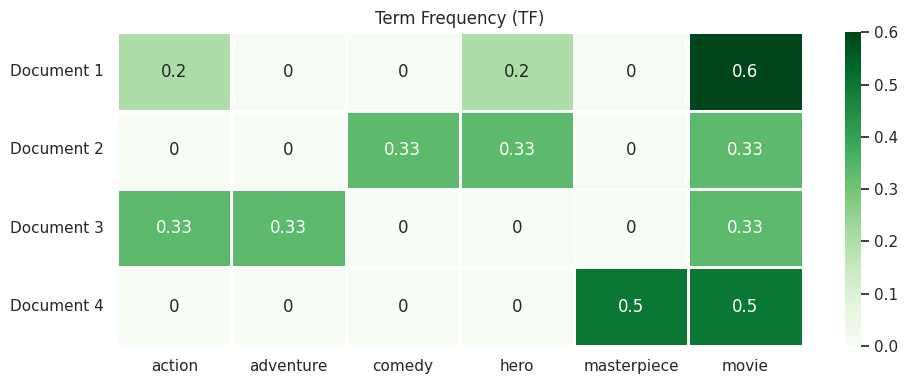

In [28]:
# --------------------------------------------------------------
# TF
# --------------------------------------------------------------

tf = count_df.div(count_df.sum(axis=1), axis=0)

print("\n")
print("="*80)
print("STEP 2 : Term Frequency (TF)")
print("="*80)

display(tf.round(3))

# --------------------------------------------------------------
# TF Heatmap
# --------------------------------------------------------------

plt.figure(figsize=(10,4))

sns.heatmap(
    tf,
    annot=True,
    cmap="Greens",
    linewidths=1
)

plt.title("Term Frequency (TF)")
plt.tight_layout()
plt.show()



In [29]:

# --------------------------------------------------------------
# Sample Documents
# --------------------------------------------------------------

documents = [

    "movie movie movie action hero",

    "movie comedy hero",

    "movie action adventure",

    "movie masterpiece"

]

doc_names = [
    "Document 1",
    "Document 2",
    "Document 3",
    "Document 4"
]

print("="*80)
print("Original Documents")
print("="*80)

for name, doc in zip(doc_names, documents):
    print(f"{name}: {doc}")


# --------------------------------------------------------------
# Document Frequency
# --------------------------------------------------------------

df = (count_df > 0).sum(axis=0)

df_table = pd.DataFrame({
    "Word": df.index,
    "Document Frequency": df.values
})

print("\n")
print("="*80)
print("STEP 3 : Document Frequency")
print("="*80)

display(df_table)



Original Documents
Document 1: movie movie movie action hero
Document 2: movie comedy hero
Document 3: movie action adventure
Document 4: movie masterpiece


STEP 3 : Document Frequency


,Word,Document Frequency
0,action,2
1,adventure,1
2,comedy,1
3,hero,2
4,masterpiece,1
5,movie,4




STEP 4 : Inverse Document Frequency (IDF)


,Word,IDF
5,movie,1.000
0,action,1.511
3,hero,1.511
1,adventure,1.916
2,comedy,1.916
4,masterpiece,1.916


/tmp/ipykernel_8522/1086123187.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


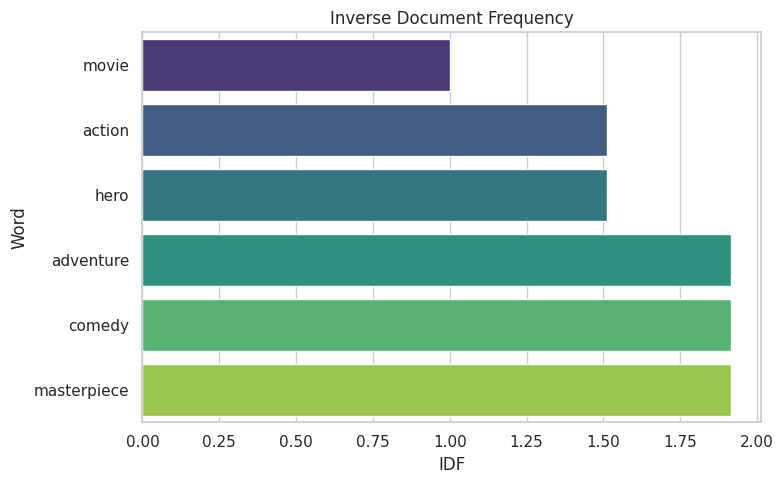

In [30]:
# --------------------------------------------------------------
# IDF
# --------------------------------------------------------------

transformer = TfidfTransformer(use_idf=True, norm=None)

transformer.fit(counts)

idf = transformer.idf_

idf_df = pd.DataFrame({

    "Word": vectorizer.get_feature_names_out(),

    "IDF": np.round(idf,3)

}).sort_values("IDF")

print("\n")
print("="*80)
print("STEP 4 : Inverse Document Frequency (IDF)")
print("="*80)

display(idf_df)

# --------------------------------------------------------------
# IDF Plot
# --------------------------------------------------------------

plt.figure(figsize=(8,5))

sns.barplot(
    data=idf_df,
    x="IDF",
    y="Word",
    palette="viridis"
)

plt.title("Inverse Document Frequency")
plt.tight_layout()
plt.show()





STEP 5 : TF-IDF Matrix


,action,adventure,comedy,hero,masterpiece,movie
Document 1,1.511,0.000,0.000,1.511,0.000,3.0
Document 2,0.000,0.000,1.916,1.511,0.000,1.0
Document 3,1.511,1.916,0.000,0.000,0.000,1.0
Document 4,0.000,0.000,0.000,0.000,1.916,1.0


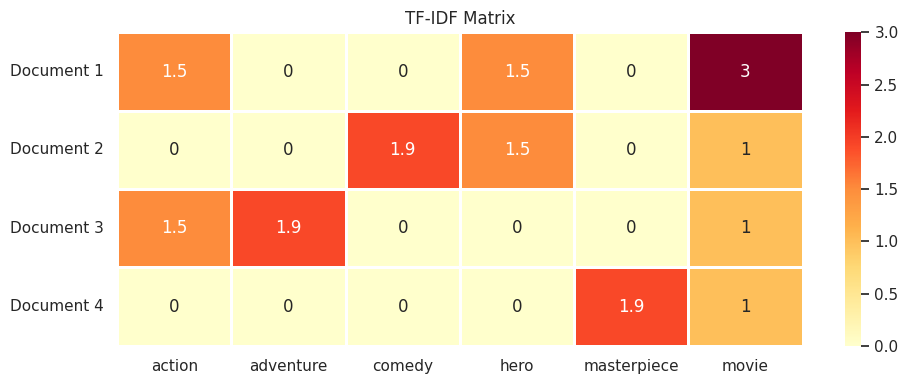

In [31]:
# --------------------------------------------------------------
# TF-IDF
# --------------------------------------------------------------

tfidf = transformer.transform(counts)

tfidf_df = pd.DataFrame(
    tfidf.toarray(),
    columns=vectorizer.get_feature_names_out(),
    index=doc_names
)

print("\n")
print("="*80)
print("STEP 5 : TF-IDF Matrix")
print("="*80)

display(tfidf_df.round(3))

# --------------------------------------------------------------
# TF-IDF Heatmap
# --------------------------------------------------------------

plt.figure(figsize=(10,4))

sns.heatmap(
    tfidf_df,
    annot=True,
    cmap="YlOrRd",
    linewidths=1
)

plt.title("TF-IDF Matrix")
plt.tight_layout()
plt.show()



In [32]:
# --------------------------------------------------------------
# TF vs IDF Comparison
# --------------------------------------------------------------

comparison = pd.DataFrame({

    "Word": vectorizer.get_feature_names_out(),

    "TF in Document 1": tf.iloc[0].values.round(3),

    "IDF": np.round(idf,3)

})

print("\n")
print("="*80)
print("TF vs IDF")
print("="*80)

display(comparison)




TF vs IDF


,Word,TF in Document 1,IDF
0,action,0.2,1.511
1,adventure,0.0,1.916
2,comedy,0.0,1.916
3,hero,0.2,1.511
4,masterpiece,0.0,1.916
5,movie,0.6,1.000


In [33]:
# ==========================================================
# Live TF-IDF Visualizer
# ==========================================================

!pip -q install gradio

import gradio as gr
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer

sns.set_theme(style="whitegrid")


# ==========================================================
# Function
# ==========================================================

def tfidf_demo(text):

    if text.strip() == "":
        return None, None, None, None, None, None, None

    # ------------------------------------------
    # Documents
    # ------------------------------------------

    docs = [d.strip() for d in text.split("\n") if d.strip()]

    vectorizer = CountVectorizer()

    counts = vectorizer.fit_transform(docs)

    words = vectorizer.get_feature_names_out()

    count_df = pd.DataFrame(
        counts.toarray(),
        columns=words,
        index=[f"Doc {i+1}" for i in range(len(docs))
    ])

    # ------------------------------------------
    # TF
    # ------------------------------------------

    tf_df = count_df.div(count_df.sum(axis=1), axis=0).round(3)

    # ------------------------------------------
    # IDF
    # ------------------------------------------

    transformer = TfidfTransformer(norm=None)

    transformer.fit(counts)

    idf_df = pd.DataFrame({

        "Word": words,

        "IDF": transformer.idf_.round(3)

    }).sort_values("IDF")

    # ------------------------------------------
    # TF-IDF
    # ------------------------------------------

    tfidf = transformer.transform(counts)

    tfidf_df = pd.DataFrame(
        tfidf.toarray().round(3),
        columns=words,
        index=[f"Doc {i+1}" for i in range(len(docs))]
    )

    # ------------------------------------------
    # TF Heatmap
    # ------------------------------------------

    plt.figure(figsize=(max(8,len(words)), max(3,len(docs))))

    sns.heatmap(
        tf_df,
        annot=True,
        cmap="Greens",
        linewidths=1
    )

    plt.title("TF Matrix")

    plt.tight_layout()

    tf_plot = plt.gcf()

    plt.close()

    # ------------------------------------------
    # IDF Plot
    # ------------------------------------------

    plt.figure(figsize=(8,4))

    sns.barplot(
        data=idf_df,
        x="IDF",
        y="Word",
        palette="viridis"
    )

    plt.title("Inverse Document Frequency")

    plt.tight_layout()

    idf_plot = plt.gcf()

    plt.close()

    # ------------------------------------------
    # TF-IDF Heatmap
    # ------------------------------------------

    plt.figure(figsize=(max(8,len(words)), max(3,len(docs))))

    sns.heatmap(
        tfidf_df,
        annot=True,
        cmap="YlOrRd",
        linewidths=1
    )

    plt.title("TF-IDF Matrix")

    plt.tight_layout()

    tfidf_plot = plt.gcf()

    plt.close()

    return (
        count_df,
        tf_df,
        idf_df,
        tfidf_df,
        tf_plot,
        idf_plot,
        tfidf_plot
    )


# ==========================================================
# Examples
# ==========================================================

examples = [[
"""movie movie movie action hero
movie comedy hero
movie action adventure
movie masterpiece"""
],

[
"""apple apple apple fruit
apple banana fruit
banana orange fruit
dragonfruit"""
],

[
"""AI AI AI machine learning
AI deep learning
machine learning
artificial intelligence"""
]
]


# ==========================================================
# Interface
# ==========================================================

demo = gr.Interface(

    fn=tfidf_demo,

    inputs=gr.Textbox(

        lines=8,

        label="Enter Documents (One Document Per Line)",

        placeholder="""movie movie movie action hero
movie comedy hero
movie action adventure
movie masterpiece"""

    ),

    outputs=[

        gr.Dataframe(label="1️⃣ Count Matrix"),

        gr.Dataframe(label="2️⃣ TF Matrix"),

        gr.Dataframe(label="3️⃣ IDF Values"),

        gr.Dataframe(label="4️⃣ TF-IDF Matrix"),

        gr.Plot(label="TF Heatmap"),

        gr.Plot(label="IDF Plot"),

        gr.Plot(label="TF-IDF Heatmap")

    ],

    examples=examples,

    title="📚 Live TF-IDF Visualizer",

    description="""
Type one document per line.

The application automatically calculates:

✅ Count Matrix

✅ TF (Term Frequency)

✅ IDF (Inverse Document Frequency)

✅ TF-IDF Matrix

and visualizes every step.
"""

)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9c300fe8fb1411c911.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# Word Cloud Visualization

## What is a Word Cloud?

A **Word Cloud** is a visual representation of text data where the size of each word indicates its importance or frequency.

- Frequently occurring words appear **larger**.
- Less frequent words appear **smaller**.

Word Clouds provide a quick overview of the most important words in a document or corpus.

---

## How Does a Word Cloud Work?

1. Collect the text.
2. Count the frequency of each word.
3. Assign larger font sizes to more frequent words.
4. Display all words in a graphical layout.

---

## Applications

- Text summarization
- Keyword extraction
- Social media analysis
- Customer reviews analysis
- Research paper analysis
- News analysis
- Topic exploration

---

## Advantages

- Easy to understand.
- Quickly highlights important words.
- Excellent for presentations and exploratory data analysis.

---

## Limitation

A Word Cloud is only a visualization tool.

It does **not** preserve:
- Grammar
- Word order
- Context
- Semantic meaning

It simply represents word frequency visually.

In [34]:
!pip install wordcloud

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


                                              Review
0  This mobile phone has an amazing camera and ba...
1  Battery backup is excellent and camera quality...
2  The phone is fast, smooth and has great perfor...
3  Excellent display with powerful processor and ...
4  Camera quality is outstanding but battery coul...
5         Amazing performance and beautiful display.
6  Fast charging and long battery life make this ...
7  I love the camera, display and overall perform...
8  Battery lasts all day and charging is super qu...
9  Best phone with excellent camera and smooth pe...


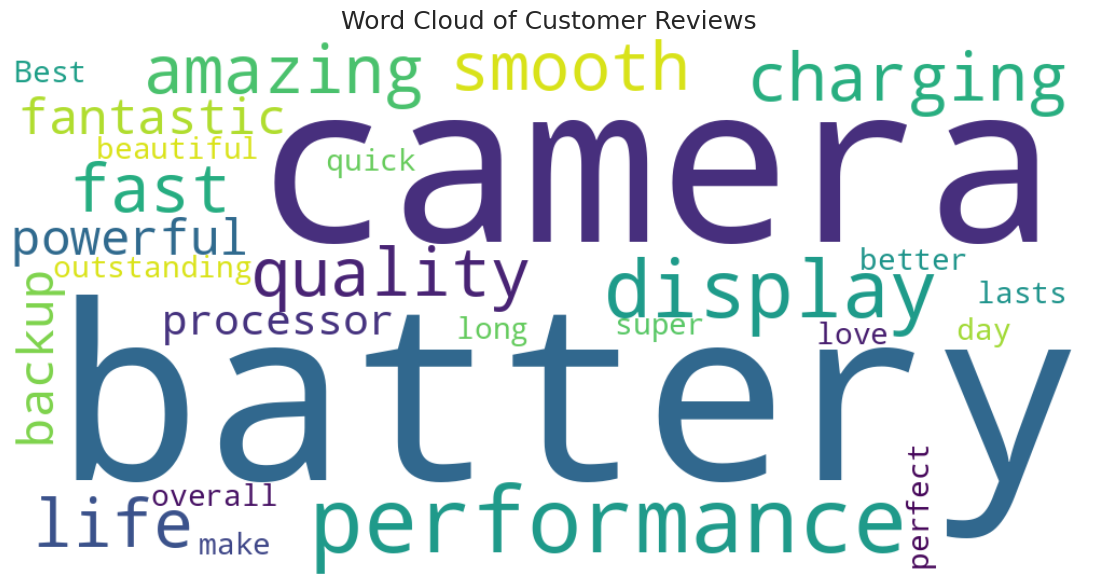

In [35]:
# ==========================================================
# WORD CLOUD VISUALIZATION - COMPLETE EXAMPLE
# ==========================================================

# Install (Run once)
# !pip install wordcloud matplotlib pandas nltk

import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS
import nltk

# Download stopwords (Run once)
nltk.download('stopwords')

# ----------------------------------------------------------
# Step 1: Create Sample Dataset
# ----------------------------------------------------------

df = pd.DataFrame({
    "Review": [
        "This mobile phone has an amazing camera and battery life.",
        "Battery backup is excellent and camera quality is fantastic.",
        "The phone is fast, smooth and has great performance.",
        "Excellent display with powerful processor and battery.",
        "Camera quality is outstanding but battery could be better.",
        "Amazing performance and beautiful display.",
        "Fast charging and long battery life make this phone perfect.",
        "I love the camera, display and overall performance.",
        "Battery lasts all day and charging is super quick.",
        "Best phone with excellent camera and smooth performance."
    ]
})

print(df)

# ----------------------------------------------------------
# Step 2: Combine all text
# ----------------------------------------------------------

text = " ".join(df["Review"])

# ----------------------------------------------------------
# Step 3: Define Stopwords
# ----------------------------------------------------------

stopwords = set(STOPWORDS)

# Add your own custom stopwords if needed
stopwords.update([
    "phone",
    "mobile",
    "great",
    "excellent"
])

# ----------------------------------------------------------
# Step 4: Generate Word Cloud
# ----------------------------------------------------------

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    stopwords=stopwords,
    colormap="viridis",
    max_words=100
).generate(text)

# ----------------------------------------------------------
# Step 5: Display Word Cloud
# ----------------------------------------------------------

plt.figure(figsize=(15,7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Customer Reviews", fontsize=18)
plt.show()


In [36]:
!pip install gradio contractions nltk spacy

!python -m spacy download en_core_web_sm

  Using cached https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.8.0/en_core_web_sm-3.8.0-py3-none-any.whl (12.8 MB)
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [37]:
!pip install -U gradio
!pip install -U youtube-comment-downloader
!pip install -U pandas matplotlib wordcloud nltk vaderSentiment

  Using cached pandas-3.0.3-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (79 kB)
  Using cached matplotlib-3.11.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (80 kB)
  Using cached nltk-3.10.0-py3-none-any.whl.metadata (3.2 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 48.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 75.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 78.3 MB/s eta 0:00:00
  Attempting uninstall: nltk
    Found existing installation: nltk 3.9.1
    Uninstalling nltk-3.9.1:
      Successfully uninstalled nltk-3.9.1
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.10.0
    Uninstalling matplotlib-3.10.0:
      Successfully uninstalled matplotlib-3.10.0
ERROR: pip's dependenc

In [3]:
import gradio as gr
import pandas as pd
import matplotlib.pyplot as plt
from youtube_comment_downloader import YoutubeCommentDownloader
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from wordcloud import WordCloud
from collections import Counter
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string
import traceback

# -----------------------------
# Download NLTK resources
# -----------------------------
nltk.download("punkt", quiet=True)

# For newer NLTK versions
try:
    nltk.download("punkt_tab", quiet=True)
except:
    pass

nltk.download("stopwords", quiet=True)

stop_words = set(stopwords.words("english"))
analyzer = SentimentIntensityAnalyzer()


def analyze(url):

    try:

        plt.close("all")

        downloader = YoutubeCommentDownloader()

        comments = []

        # -----------------------------
        # Download comments
        # -----------------------------
        for comment in downloader.get_comments_from_url(url):

            text = comment.get("text", "").strip()

            if text:
                comments.append(text)

            if len(comments) >= 200:
                break

        if len(comments) == 0:
            return "❌ No comments found.", None, None, None

        sentiments = []
        all_words = []

        # -----------------------------
        # Sentiment Analysis
        # -----------------------------
        for c in comments:

            score = analyzer.polarity_scores(c)["compound"]

            if score >= 0.05:
                sentiments.append("Positive")

            elif score <= -0.05:
                sentiments.append("Negative")

            else:
                sentiments.append("Neutral")

            text = c.lower()

            text = text.translate(
                str.maketrans("", "", string.punctuation)
            )

            try:
                words = word_tokenize(text)
            except:
                words = text.split()

            words = [
                w for w in words
                if w not in stop_words and w.isalpha()
            ]

            all_words.extend(words)

        # -----------------------------
        # DataFrame
        # -----------------------------
        df = pd.DataFrame({
            "Comment": comments,
            "Sentiment": sentiments
        })

        positive = sentiments.count("Positive")
        negative = sentiments.count("Negative")
        neutral = sentiments.count("Neutral")

        summary = f"""
YouTube Comment Analysis

Total Comments : {len(df)}

Positive : {positive}

Negative : {negative}

Neutral : {neutral}
"""

        # -----------------------------
        # Word Cloud
        # -----------------------------
        if len(all_words) == 0:
            all_words = ["No", "Words"]

        wc = WordCloud(
            width=900,
            height=450,
            background_color="white"
        ).generate(" ".join(all_words))

        fig1 = plt.figure(figsize=(10,5))
        plt.imshow(wc, interpolation="bilinear")
        plt.axis("off")
        plt.tight_layout()

        # -----------------------------
        # Top Words
        # -----------------------------
        common = Counter(all_words).most_common(10)

        words = [i[0] for i in common]
        counts = [i[1] for i in common]

        fig2 = plt.figure(figsize=(8,4))
        plt.bar(words, counts)
        plt.xticks(rotation=45)
        plt.title("Top 10 Words")
        plt.tight_layout()

        return summary, fig1, fig2, df

    except Exception:

        return traceback.format_exc(), None, None, None


demo = gr.Interface(
    fn=analyze,

    inputs=gr.Textbox(
        label="YouTube Video URL",
        placeholder="Paste YouTube URL here..."
    ),

    outputs=[
        gr.Textbox(label="Summary"),
        gr.Plot(label="Word Cloud"),
        gr.Plot(label="Top 10 Words"),
        gr.Dataframe(label="Comments & Sentiment")
    ],

    title="🎥 YouTube Comment Sentiment Analyzer",

    description="Paste any public YouTube video URL and analyze the first 200 comments."
)

demo.launch(debug=True)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://0216bb78be43fa0a9a.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://c2b45f5877185ebb75.gradio.live
Killing tunnel 127.0.0.1:7861 <> https://0216bb78be43fa0a9a.gradio.live


# Word2Vec - Learning Word Meanings

## The Problem

Traditional text representations such as:

- One-Hot Encoding (OHE)
- Bag of Words (BoW)
- TF-IDF

can tell **whether a word exists**, but they **cannot understand its meaning**.

For example:

King
Queen
Prince
Princess

To a computer:

King = [1,0,0,0]
Queen = [0,1,0,0]

These vectors are equally distant even though **King and Queen are semantically similar.**

Similarly,

Car
Bus
Truck

are all vehicles, but OHE treats them as completely unrelated.

---

## Solution

Instead of assigning random vectors,

Word2Vec **learns vector representations** from large amounts of text.

Words appearing in similar contexts receive similar vectors.

Example:

King → [0.61, -0.22, 0.74, ...]

Queen → [0.59, -0.20, 0.72, ...]

These vectors become very close.

This is called a **Word Embedding**.

Word2Vec was introduced by Google in 2013.

In [1]:
# Sample sentences

sentences = [
    "king is a strong man",
    "queen is a wise woman",
    "boy is a young man",
    "girl is a young woman",
    "prince is a young king",
    "princess is a young queen",
    "man is strong",
    "woman is pretty",
]

for s in sentences:
    print(s)

king is a strong man
queen is a wise woman
boy is a young man
girl is a young woman
prince is a young king
princess is a young queen
man is strong
woman is pretty


In [2]:
sentence = "the cat sat on the mat".split()

window_size = 2

print("Sentence:\n", sentence)
print()

for i, word in enumerate(sentence):

    start = max(0, i-window_size)
    end = min(len(sentence), i+window_size+1)

    context = []

    for j in range(start, end):
        if j != i:
            context.append(sentence[j])

    print(f"Target : {word}")
    print(f"Context: {context}")
    print("-"*40)

Sentence:
 ['the', 'cat', 'sat', 'on', 'the', 'mat']

Target : the
Context: ['cat', 'sat']
----------------------------------------
Target : cat
Context: ['the', 'sat', 'on']
----------------------------------------
Target : sat
Context: ['the', 'cat', 'on', 'the']
----------------------------------------
Target : on
Context: ['cat', 'sat', 'the', 'mat']
----------------------------------------
Target : the
Context: ['sat', 'on', 'mat']
----------------------------------------
Target : mat
Context: ['on', 'the']
----------------------------------------


In [4]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 19.7 MB/s eta 0:00:00


In [5]:
from gensim.models import Word2Vec

sentences = [
    "king is a strong man".split(),
    "queen is a wise woman".split(),
    "boy is a young man".split(),
    "girl is a young woman".split(),
    "prince is a young king".split(),
    "princess is a young queen".split(),
    "man is strong".split(),
    "woman is pretty".split(),
]

model = Word2Vec(
    sentences,
    vector_size=20,
    window=2,
    min_count=1,
    workers=1,
    epochs=300
)

print("Vocabulary\n")
print(model.wv.index_to_key)

print("\nEmbedding of KING\n")
print(model.wv["king"])

Vocabulary

['is', 'a', 'young', 'woman', 'man', 'queen', 'strong', 'king', 'pretty', 'princess', 'prince', 'girl', 'boy', 'wise']

Embedding of KING

[ 3.77665795e-02 -3.21108103e-02 -4.25402075e-02 -1.39783800e-03
 -1.53229088e-02  3.80434170e-02  3.22724804e-02  2.33408762e-04
  1.75531791e-03  1.08302925e-02  4.11124490e-02 -4.95760702e-02
 -2.55464856e-05  1.48676913e-02 -3.49838287e-03  4.23149131e-02
  5.36939912e-02  3.09187230e-02 -8.67055077e-03  3.66217084e-02]


# Similar Words



In [6]:
print("Words similar to KING\n")

for word, score in model.wv.most_similar("king"):

    print(f"{word:12} {score:.3f}")

print()

print("Similarity")

print("King vs Queen :",
      model.wv.similarity("king","queen"))

print("King vs Princess :",
      model.wv.similarity("king","princess"))

print("King vs Woman :",
      model.wv.similarity("king","woman"))

Words similar to KING

wise         0.452
strong       0.338
girl         0.184
prince       0.129
queen        0.101
is           0.047
woman        0.009
man          -0.038
princess     -0.056
pretty       -0.076

Similarity
King vs Queen : 0.10112743
King vs Princess : -0.05577344
King vs Woman : 0.008830659


# Visualizing Word2Vec



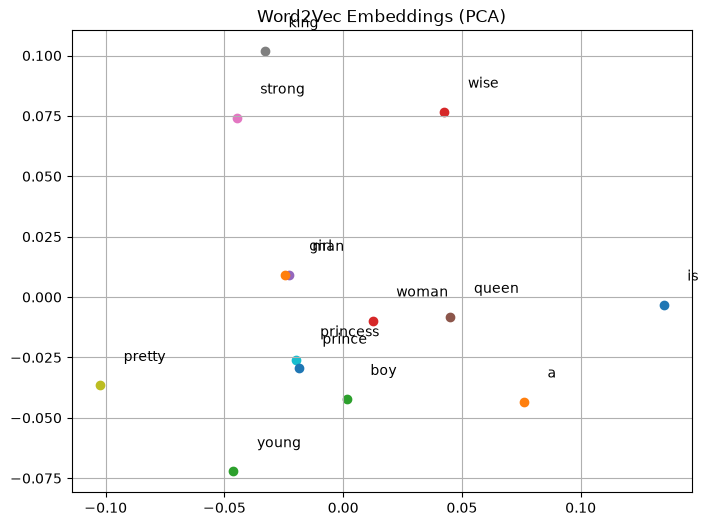

In [7]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

words = list(model.wv.index_to_key)

vectors = [model.wv[w] for w in words]

pca = PCA(n_components=2)

points = pca.fit_transform(vectors)

plt.figure(figsize=(8,6))

for i, word in enumerate(words):

    x = points[i][0]
    y = points[i][1]

    plt.scatter(x,y)
    plt.text(x+0.01,y+0.01,word)

plt.title("Word2Vec Embeddings (PCA)")
plt.grid(True)
plt.show()

**FRONT END**

In [8]:
import gradio as gr
import pandas as pd
from gensim.models import Word2Vec
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# -----------------------------
# Sample Corpus
# -----------------------------

sample_text = """king is a strong man
queen is a wise woman
boy is a young man
girl is a young woman
prince is a young king
princess is a young queen
man is strong
woman is pretty
king queen prince princess
man woman boy girl"""

model = None


# ---------------------------------
# Create Context Pairs
# ---------------------------------

def generate_context(text, window):

    sentences = [line.lower().split() for line in text.strip().split("\n")]

    rows = []

    for sentence in sentences:

        for i, target in enumerate(sentence):

            start = max(0, i-window)
            end = min(len(sentence), i+window+1)

            context = []

            for j in range(start,end):
                if j!=i:
                    context.append(sentence[j])

            rows.append([target,", ".join(context)])

    return pd.DataFrame(rows,columns=["Target Word","Context Words"])


# ---------------------------------
# Train Word2Vec
# ---------------------------------

def train_model(text, vector_size, window, epochs):

    global model

    sentences = [line.lower().split() for line in text.strip().split("\n")]

    model = Word2Vec(
        sentences,
        vector_size=vector_size,
        window=window,
        min_count=1,
        workers=1,
        epochs=epochs
    )

    vocab = model.wv.index_to_key

    info = f"""
Vocabulary Size : {len(vocab)}

Vocabulary

{", ".join(vocab)}

Embedding Dimension : {vector_size}

Training Completed Successfully
"""

    return info


# ---------------------------------
# Similar Words
# ---------------------------------

def similar_words(word):

    global model

    if model is None:
        return pd.DataFrame()

    if word not in model.wv:
        return pd.DataFrame()

    sim = model.wv.most_similar(word)

    return pd.DataFrame(sim,columns=["Word","Similarity"])


# ---------------------------------
# Show Vector
# ---------------------------------

def show_vector(word):

    global model

    if model is None:
        return "Train model first."

    if word not in model.wv:
        return "Word not found."

    vector = model.wv[word]

    return str(vector)


# ---------------------------------
# PCA Plot
# ---------------------------------

def plot_embeddings():

    global model

    if model is None:
        return None

    words = model.wv.index_to_key

    vectors = [model.wv[w] for w in words]

    pca = PCA(n_components=2)

    points = pca.fit_transform(vectors)

    fig = plt.figure(figsize=(8,6))

    for i,word in enumerate(words):

        plt.scatter(points[i,0],points[i,1])

        plt.text(points[i,0]+0.02,
                 points[i,1]+0.02,
                 word,
                 fontsize=10)

    plt.title("Word2Vec Embeddings (PCA)")
    plt.grid(True)

    return fig


# ---------------------------------
# GUI
# ---------------------------------

with gr.Blocks(theme=gr.themes.Soft(),
               title="Word2Vec Learning Lab") as demo:

    gr.Markdown(
    """
# 🧠 Word2Vec Interactive Learning Lab

Learn Word2Vec step-by-step.

### Workflow

1. Enter a corpus
2. Observe Context Windows
3. Train Word2Vec
4. Find Similar Words
5. Inspect Word Vectors
6. Visualize Embeddings
""")

    corpus = gr.Textbox(
        value=sample_text,
        lines=12,
        label="Corpus"
    )

    with gr.Tab("Step 1 : Context Window"):

        window_slider = gr.Slider(
            1,
            4,
            value=2,
            step=1,
            label="Window Size"
        )

        context_btn = gr.Button("Generate Training Pairs")

        context_table = gr.Dataframe()

        context_btn.click(
            generate_context,
            [corpus,window_slider],
            context_table
        )

    with gr.Tab("Step 2 : Train Model"):

        vector_slider = gr.Slider(
            10,
            100,
            value=20,
            step=10,
            label="Vector Size"
        )

        epoch_slider = gr.Slider(
            50,
            500,
            value=200,
            step=50,
            label="Epochs"
        )

        train_btn = gr.Button("Train Word2Vec")

        training_info = gr.Textbox(lines=10)

        train_btn.click(
            train_model,
            [corpus,
             vector_slider,
             window_slider,
             epoch_slider],
            training_info
        )

    with gr.Tab("Step 3 : Explore Words"):

        word_box = gr.Textbox(label="Enter Word")

        similar_btn = gr.Button("Find Similar Words")

        similar_table = gr.Dataframe()

        vector_btn = gr.Button("Show Word Vector")

        vector_output = gr.Textbox(lines=8)

        similar_btn.click(
            similar_words,
            word_box,
            similar_table
        )

        vector_btn.click(
            show_vector,
            word_box,
            vector_output
        )

    with gr.Tab("Step 4 : Visualization"):

        plot_btn = gr.Button("Generate PCA Plot")

        plot = gr.Plot()

        plot_btn.click(
            plot_embeddings,
            outputs=plot
        )

demo.launch()

/tmp/ipykernel_10845/4012543688.py:167: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=gr.themes.Soft(),


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b48cc561c543d82d90.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [9]:
# ==========================================================
# Word2Vec Real World Demo
# Semantic Product Search using Word2Vec
# ==========================================================

import gradio as gr
from gensim.models import Word2Vec
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------------------------------------
# Sample Product Database
# ----------------------------------------------------------

products = [
    "Samsung Galaxy smartphone",
    "Apple iPhone mobile",
    "Android smartphone",
    "OnePlus mobile phone",
    "Gaming laptop",
    "Business notebook computer",
    "Wireless headphones",
    "Bluetooth earbuds",
    "LED television",
    "Smart TV",
    "Running shoes",
    "Sports sneakers",
    "Leather wallet",
    "Coffee machine",
    "Microwave oven",
    "Refrigerator",
    "Digital camera",
    "DSLR camera",
    "Football",
    "Cricket bat",
    "Tennis racket",
    "Office chair",
    "Study table",
    "Desktop computer",
    "Gaming keyboard",
    "Mechanical keyboard",
]

# ----------------------------------------------------------
# Build Corpus
# ----------------------------------------------------------

sentences = [p.lower().split() for p in products]

model = Word2Vec(
    sentences,
    vector_size=50,
    window=3,
    min_count=1,
    epochs=500,
    workers=1
)

# ----------------------------------------------------------
# Traditional Search
# ----------------------------------------------------------

def traditional_search(query):

    query = query.lower()

    results = []

    for product in products:

        if query in product.lower():

            results.append(product)

    if len(results)==0:
        return "❌ No Product Found"

    return "\n".join(results)

# ----------------------------------------------------------
# Word2Vec Semantic Search
# ----------------------------------------------------------

def semantic_search(query):

    query = query.lower().strip()

    if query not in model.wv:

        return (
            "Word not present in vocabulary.\n"
            "Try words like:\n"
            "mobile, smartphone, laptop, keyboard, shoes"
        ), pd.DataFrame(), None

    similar = model.wv.most_similar(query, topn=5)

    similar_words = [query]

    recommendations = []

    for word,score in similar:

        similar_words.append(word)

    for product in products:

        text = product.lower()

        if any(word in text for word in similar_words):

            recommendations.append(product)

    recommendations = list(dict.fromkeys(recommendations))

    df = pd.DataFrame(similar,
                      columns=["Similar Word","Similarity"])

    # PCA Visualization

    words = list(model.wv.index_to_key)

    vectors = np.array([model.wv[w] for w in words])

    pca = PCA(n_components=2)

    points = pca.fit_transform(vectors)

    fig = plt.figure(figsize=(8,6))

    for i,w in enumerate(words):

        if w==query:
            plt.scatter(points[i,0],points[i,1],s=150)
            plt.text(points[i,0],
                     points[i,1],
                     w,
                     fontsize=12)

        else:

            plt.scatter(points[i,0],points[i,1])
            plt.text(points[i,0],
                     points[i,1],
                     w,
                     fontsize=9)

    plt.title("Word2Vec Embedding Space")
    plt.grid(True)

    return "\n".join(recommendations), df, fig

# ----------------------------------------------------------
# GUI
# ----------------------------------------------------------

with gr.Blocks(theme=gr.themes.Soft()) as demo:

    gr.Markdown(
    """
# 🛒 Word2Vec Real-World Demo

## Semantic Product Search

### Problem

Traditional search only understands **exact keywords**.

Searching

**mobile**

cannot find

**smartphone**

---

### Solution

Word2Vec learns word meanings.

It understands

mobile ≈ smartphone ≈ iphone ≈ android

and recommends relevant products.
""")

    query = gr.Textbox(
        label="Search Product",
        placeholder="Try : mobile, smartphone, laptop, keyboard, shoes"
    )

    with gr.Row():

        normal_btn = gr.Button("Traditional Search")

        semantic_btn = gr.Button("Word2Vec Search")

    with gr.Row():

        traditional_output = gr.Textbox(
            label="Traditional Search Result",
            lines=10
        )

        semantic_output = gr.Textbox(
            label="Semantic Recommendations",
            lines=10
        )

    similarity_table = gr.Dataframe(
        label="Nearest Words Learned by Word2Vec"
    )

    embedding_plot = gr.Plot(
        label="Embedding Visualization"
    )

    normal_btn.click(
        traditional_search,
        query,
        traditional_output
    )

    semantic_btn.click(
        semantic_search,
        query,
        [semantic_output,
         similarity_table,
         embedding_plot]
    )

demo.launch()

/tmp/ipykernel_10845/1655447925.py:159: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as demo:


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://2e7c6c8f193b2fc6eb.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
